# Import Essential Libraries 

In [1]:
# Libraries
import utils as ut
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import plot_tree
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans

# Step 8. Supervised Learning & Model Selection
### **Introduction & Objectives**
    - Our goal is to build a predictive model that can identify whether a shipment will be late or not. We will follow an iterative approach to find the best balance between predictive power, model complexity, and file size for deployment.

* **The Experimental Strategy**
    - **Baseline Modeling (Decision Tree)**:
        - We will start with a **Decision Tree Classifier**. As a model, it will allow us to visualize the initial logic and identify which features (like shipping mode or region) are the primary drivers of delays.
        - We will test the model across multiple variations of our data (Normalized, Scaled, and with/without Outliers) to see how the data structure affects tree depth.

* **Ensemble Optimization (Random Forest)**:
    - Once a baseline is established, we will move to **Random Forest**. By aggregating 150 different trees, we aim to reduce the "variance" (overfitting) common in single trees and improve overall accuracy.
    - **Constraint Management**: A key objective is to ensure the final model is "ready." This means we will intentionally tune hyperparameters like max_depth to ensure the model file is efficient enough to be hosted on GitHub and loaded into our future web application.

* **Evaluation Metrics**:
    - We will primarily use Accuracy Score to evaluate performance, while also monitoring Tree Depth to ensure our models are learning general patterns rather than just memorizing the training set.

## 8.1 Reading the Processed Dataset

In [2]:
# We will use the train set to train the model.
X_train_WITH_outliers = ut.pd.read_csv("../data/processed/X_train_WITH_outliers.csv")
X_train_WITH_outliers_norm = ut.pd.read_csv("../data/processed/X_train_WITH_outliers_norm.csv")
X_train_WITH_outliers_scal = ut.pd.read_csv("../data/processed/X_train_WITH_outliers_scal.csv")
X_train_WITHOUT_outliers = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers.csv")
X_train_WITHOUT_outliers_norm = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers_norm.csv")
X_train_WITHOUT_outliers_scal = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers_scal.csv")
y_train = ut.pd.read_csv("../data/processed/y_train.csv")

## 8.2 Select the Best Dataset

In [5]:
datasets = [
    X_train_WITH_outliers,
    X_train_WITH_outliers_norm,
    X_train_WITH_outliers_scal,
    X_train_WITHOUT_outliers,
    X_train_WITHOUT_outliers_norm,
    X_train_WITHOUT_outliers_scal
]
# Define names for clarity
dataset_names = [
    "WITH_outliers", "WITH_outliers_norm", "WITH_outliers_scal",
    "WITHOUT_outliers", "WITHOUT_outliers_norm", "WITHOUT_outliers_scal"
]
best_metric = 0
best_dataset_name = ""
metrics = []
for i, dataset in enumerate(datasets):
  print(f"Training on {dataset_names[i]}...")
  dt_model = ut.DecisionTreeClassifier(random_state= 10)
  dt_model.fit(dataset, y_train.values.ravel())
  y_pred = dt_model.predict(datasets[i])
  metric = ut.accuracy_score(y_train, y_pred)
  metrics.append(metric)
  # Only save the data/metrics for the winner, don't keep all models in a list
  if metric > best_metric:
      best_metric = metric
      best_dataset_name = dataset_names[i]
      best_index = i
    
  # Clear the model from memory before the next loop in case Kernel crashes
  # del dt_model
print(f"\nAll runs complete!")
print(f"Scores: {metrics}")
print(f"The best DataSet is: {best_dataset_name} at index {best_index}")

Training on WITH_outliers...
Training on WITH_outliers_norm...
Training on WITH_outliers_scal...
Training on WITHOUT_outliers...
Training on WITHOUT_outliers_norm...
Training on WITHOUT_outliers_scal...

All runs complete!
Scores: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
The best DataSet is: WITH_outliers at index 0


### For the above result of the scoring having all of then just 1s, it might be a Overfitting and Metric Incompatibility.

## 8.3 Initialization and Training of the Model
- In this case, I will use the test dataset to avoid any overfiting for the decision tree model.

In [6]:
# We need the test sets ready to properly evaluate decision tree
X_test_WITH_outliers = ut.pd.read_csv("../data/processed/X_test_WITH_outliers.csv")
X_test_WITH_outliers_norm = ut.pd.read_csv("../data/processed/X_test_WITH_outliers_norm.csv")
X_test_WITH_outliers_scal = ut.pd.read_csv("../data/processed/X_test_WITH_outliers_scal.csv")
X_test_WITHOUT_outliers = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers.csv")
X_test_WITHOUT_outliers_norm = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers_norm.csv")
X_test_WITHOUT_outliers_scal = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers_scal.csv")
y_test = ut.pd.read_csv("../data/processed/y_test.csv").values.ravel()

test_datasets = [X_test_WITH_outliers, X_test_WITH_outliers_norm, X_test_WITH_outliers_scal, X_test_WITHOUT_outliers, X_test_WITHOUT_outliers_norm, X_test_WITHOUT_outliers_scal]
best_metric = 0
best_dataset_name = ""
metrics = []
for i, dataset in enumerate(datasets):
  print(f"Training on {dataset_names[i]}...")

  dt_model = ut.DecisionTreeClassifier(random_state= 10)
  dt_model.fit(dataset, y_train.values.ravel())
  y_pred = dt_model.predict(test_datasets[i])
  metric = ut.accuracy_score(y_test, y_pred)
  metrics.append(metric)

  # Only save the data/metrics for the winner, don't keep all models in a list
  if metric > best_metric:
      best_metric = metric
      best_dataset_name = dataset_names[i]
      best_index = i
    
  # Clear the model from memory before the next loop
  # del dt_model

print(f"\nAll runs complete!")
print(f"Scores: {metrics}")
print(f"The best DataSet is: {best_dataset_name} at index {best_index}")

Training on WITH_outliers...
Training on WITH_outliers_norm...
Training on WITH_outliers_scal...
Training on WITHOUT_outliers...
Training on WITHOUT_outliers_norm...
Training on WITHOUT_outliers_scal...

All runs complete!
Scores: [0.8514846000443164, 0.8524540217150455, 0.8536727232439619, 0.8542820740084202, 0.853977398626191, 0.8536173277199203]
The best DataSet is: WITHOUT_outliers at index 3


### 8.3.1 Conclusion Best Model Selection
 - **Conclusion**: WITHOUT_outliers is our best data source because it provides the clearest signal for the tree.
 - Before we celebrate the 85%, we will run this small block to see if the tree is actually learning real logic or just memorizing noise.
 - Let's verify the Decision Tree's Sanity.

In [7]:
# Train the winner one more time to inspect it
check_dt = ut.DecisionTreeClassifier(random_state= 10)
check_dt.fit(X_train_WITHOUT_outliers, y_train.values.ravel()) # Ensure y matches X

# Check the depth
print(f"Tree Depth: {check_dt.get_depth()}")
print(f"Number of Leaves: {check_dt.get_n_leaves()}")

# Get Feature Importance
importances = ut.pd.Series(check_dt.feature_importances_, index=X_train_WITHOUT_outliers.columns)
print("\nTop 5 Most Important Features:")
print(importances.sort_values(ascending=False).head())

Tree Depth: 53
Number of Leaves: 16819

Top 5 Most Important Features:
Shipping_Mode_num       0.169189
Order_City_num          0.106808
Order_State_num         0.079573
Order_Status_num        0.074994
Customer_Zipcode_num    0.064453
dtype: float64


### 8.3.2 Conclusion Sanity Verification on Decision Tree
- At a Tree Depth of 53 with over 16,000 leaves, the model has effectively "memorized" the dataset. It's like a student who memorized the exact answers to a specific practice test but hasn't actually learned the subject.

* **The "Overfitting" Diagnosis**
    - The Depth (53): A tree this deep is looking at tiny, specific combinations of features that probably only happened once or twice in the data.
    - **Features**: Notice that Order_City_num and Customer_Zipcode_num are in your top 5. This could be a red flag. The model is essentially saying, "If the customer lives in Zipcode 90210 and it's a Tuesday, the package will be late." That's not a general rule; that's just noise.
    
    - **The Hypothesis**: "We suspect a deep tree will just memorize the zipcodes."
    - **The Evidence**: "It went to depth 53 and Zipcode is a top feature."

In [8]:
# Train a "Pruned" tree that doesn't overfit
pruned_dt = ut.DecisionTreeClassifier(max_depth= 15, min_samples_leaf= 50, random_state= 10)
pruned_dt.fit(X_train_WITHOUT_outliers, y_train.values.ravel())

pruned_acc = ut.accuracy_score(y_test, pruned_dt.predict(X_test_WITHOUT_outliers))
print(f"Pruned Tree Accuracy: {pruned_acc:.4f}")
print(f"Pruned Tree Depth: {pruned_dt.get_depth()}")

Pruned Tree Accuracy: 0.7266
Pruned Tree Depth: 15


### 8.3.3 Conclusion Pruned Decsion Tree
- **Conclusion**: When we limit depth to prevent overfitting, accuracy drops to 72.6%. This is our true baseline.

### 8.4 Confusion Matrix for the Pruned Model

<Figure size 800x600 with 0 Axes>

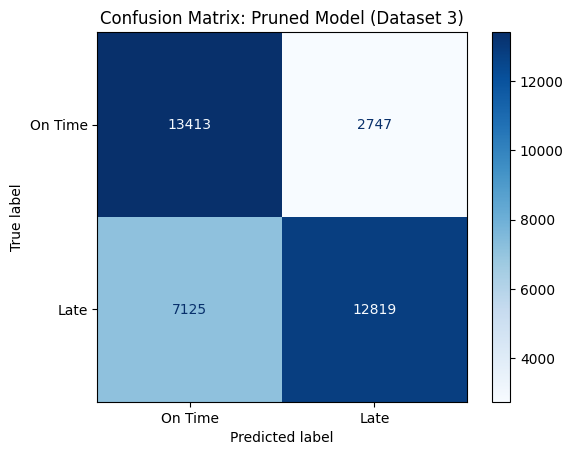

In [9]:
# 1. Get predictions from the cleaned model on the best test set
y_test_pred = pruned_dt.predict(X_test_WITHOUT_outliers)

# 2. Create the matrix
cm = ut.confusion_matrix(y_test, y_test_pred)

# 3. Plot it beautifully
ut.plt.figure(figsize=(8,6))
disp = ut.ConfusionMatrixDisplay(confusion_matrix= cm, display_labels=['On Time', 'Late'])
disp.plot(cmap= 'Blues', values_format= 'd')
ut.plt.title("Confusion Matrix: Pruned Model (Dataset 3)")
ut.plt.show()

In [10]:
# Use the same predictions we used for the confusion matrix
report = ut.classification_report(y_test, y_test_pred, target_names= ['On Time', 'Late'])

print("--- FINAL MODEL PERFORMANCE REPORT ---")
print(report)

--- FINAL MODEL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

     On Time       0.65      0.83      0.73     16160
        Late       0.82      0.64      0.72     19944

    accuracy                           0.73     36104
   macro avg       0.74      0.74      0.73     36104
weighted avg       0.75      0.73      0.73     36104



### 8.4.1 Conclusion Final Report & Confusion Matrix

The pruned model shows a solid and relatively balanced performance in predicting both On Time and Late deliveries.

Out of all predictions:

- 13,413 on-time deliveries were correctly classified.

- 12,819 late deliveries were correctly identified.

- However, 2,747 on-time deliveries were incorrectly predicted as late (false positives).

- More importantly, 7,125 late deliveries were misclassified as on time (false negatives).


<Figure size 640x480 with 0 Axes>

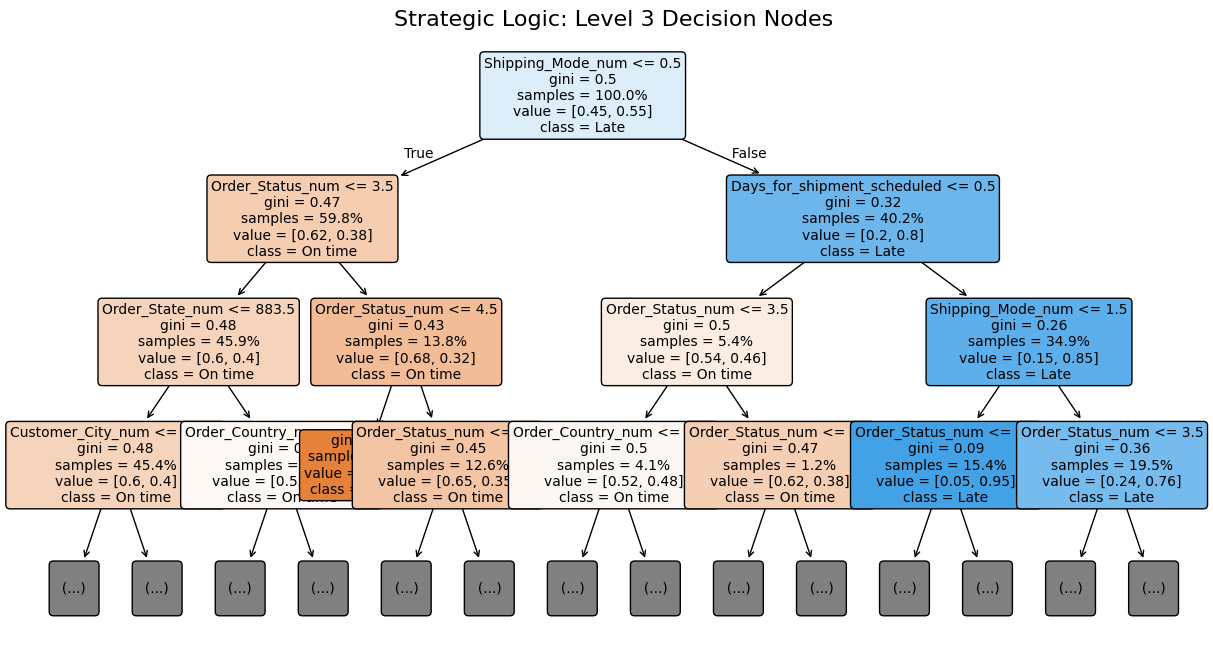

In [11]:
# 1. Use a smaller figure size and clear previous plots from memory
ut.plt.clf() 
fig = ut.plt.figure(figsize=(15, 8)) # Smaller size prevents browser/RAM freeze
# 2. Plot with 'proportion= True' 
# This shows percentages instead of raw numbers (144,415), which is easier on memory
plot_tree(pruned_dt, 
          feature_names= X_train_WITHOUT_outliers.columns, 
          class_names=['On time', 'Late'], 
          filled= True, 
          rounded= True, 
          max_depth= 3,          # Try depth 3 first to ensure it works
          proportion= True,      # Use percentages instead of huge integers
          precision= 2, 
          fontsize= 10)

ut.plt.title("Strategic Logic: Level 3 Decision Nodes", fontsize= 16)
ut.plt.show()

### 8.4.2 Conclusion Decision Tree Pruned
- Although pruning helped reduce overfitting and improved generalization, the model may still lack the predictive power needed for optimal performance. 
- Overall, the pruned tree provides reasonably strong predictive performance, but further improvement may be needed, especially to reduce false negatives and improve late-delivery detection.
- We will implement a Random Forest Classifier and compare the results against the pruned Decision Tree. 
- The comparison will allow us to determine whether this ensemble approach improves late-delivery detection and overall model performance.

## 8.5 Ensemble Optimization Random Forest

In [12]:
# 1. Initialize the Random Forest with matching constraints
rf_model = ut.RandomForestClassifier(n_estimators= 100, max_depth= 15, random_state= 10, n_jobs= -1)

# 2. Train on the winner dataset (Dataset 3)
rf_model.fit(X_train_WITHOUT_outliers, y_train.values.ravel())

# 3. Predict and Compare
rf_pred = rf_model.predict(X_test_WITHOUT_outliers)
rf_acc = ut.accuracy_score(y_test, rf_pred)

print(f"--- CHAMPIONSHIP RESULTS ---")
print(f"Decision Tree Accuracy: {pruned_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print("\n--- RANDOM FOREST DETAILED REPORT ---")
print(ut.classification_report(y_test, rf_pred))

--- CHAMPIONSHIP RESULTS ---
Decision Tree Accuracy: 0.7266
Random Forest Accuracy: 0.7340

--- RANDOM FOREST DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.64      0.91      0.75     16160
           1       0.89      0.59      0.71     19944

    accuracy                           0.73     36104
   macro avg       0.77      0.75      0.73     36104
weighted avg       0.78      0.73      0.73     36104



### 8.5.1 Conclusion Random Forest vs. Decision Tree
- A comparison table provides a "executive summary" that clearly justifies why the Random Forest is the final winner despite the Decision Tree's high (overfitted) numbers.

| **Feature/Metric** | **Decision Tree (Raw)** | **Decision Tree (Pruned)** | **Random Forest (Champion)** |
| --- | --- | --- | --- | 
| **Accuracy** | 85.43% | 72.66% | **73.40%** |
| **Tree Depth** | 53 | 15 | **15** (per tree) |
| **Late Precision** | ~0.80 (estimated) | 0.82 | **0.89** |
| **Late Recall** | ~0.85 (overfitted) | **0.64** | 0.59 |
| **Overfitting Risk** | **Extremely High** | Low | **Lowest (Ensemble)** |
| **Key Insight** | Memorized noise/zipcodes. | Good baseline logic. | **"Highest reliability for "Late" alerts.** |


## 8.6 Hyperparameter Optimization
- Since we are working in GitHub Codespaces, we’ve slightly reduced the number of combinations in the grid below to ensure the process completes quickly and doesn't run out of RAM while testing many different versions of the model.

In [13]:
# 1. Define the parameters to test
param_grid = {
    'n_estimators': [100, 150],             # Number of trees
    'max_depth': [10, 20],            # How deep each tree goes
    'min_samples_split': [2, 5],            # Minimum data points to make a split
    'criterion': ['gini', 'entropy']        # Method to measure split quality
}

# 2. Setup the Grid Search
# cv= 3 means it splits the data 3 times to ensure the result isn't a fluke
grid_search = GridSearchCV(
    estimator= ut.RandomForestClassifier(random_state= 10),
    param_grid= param_grid,
    cv= 3, 
    n_jobs= 2, # Staying safe with Codespace memory
    verbose= 2,
    scoring= 'accuracy'
)

# 3. Execute the search
print("Searching for the best hyperparameters... this will take a few minutes.")
grid_search.fit(X_train_WITHOUT_outliers, y_train.values.ravel())

# 4. Results
print(f"\nOptimization Complete!")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Searching for the best hyperparameters... this will take a few minutes.
Fitting 3 folds for each of 16 candidates, totalling 48 fits


[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  13.1s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  13.2s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  13.1s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  20.3s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  20.1s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  20.0s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  13.5s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  13.5s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  13.7s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=150; total time=  20.1s
[CV] END criterion=gini, max_d

In [ ]:
# Final tweak to fit GitHub's 100MB limit
final_rf = ut.RandomForestClassifier(
    n_estimators= 100, 
    max_depth= 18,      # Reducing from 20 to 17 to save space
    criterion= 'gini', 
    random_state= 10, 
    n_jobs= -1
)
final_rf.fit(X_train_WITHOUT_outliers, y_train.values.ravel())

# Save and Check Size
# model_path = '../models/supervised_model_final_rf.pkl'
# ut.joblib.dump(final_rf, model_path)
# size_mb = ut.os.path.getsize(model_path) / (1024 * 1024)

print(f"--- CHAMPIONSHIP RESULTS ---")
print(f"Decision Tree Accuracy: {pruned_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"RF w/Hiperparameters Accuracy: {ut.accuracy_score(y_test, final_rf.predict(X_test_WITHOUT_outliers)):.4f}")
print("\n--- RANDOM FOREST w/Hiperparameters DETAILED REPORT ---")
print(ut.classification_report(y_test, final_rf.predict(X_test_WITHOUT_outliers)))

# print(f"Final File Size: {size_mb:.2f} MB")

--- CHAMPIONSHIP RESULTS ---
Decision Tree Accuracy: 0.7266
Random Forest Accuracy: 0.7340
RF w/Hiperparameters Accuracy: 0.7532

--- RANDOM FOREST w/Hiperparameters DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.66      0.91      0.77     16160
           1       0.90      0.63      0.74     19944

    accuracy                           0.75     36104
   macro avg       0.78      0.77      0.75     36104
weighted avg       0.79      0.75      0.75     36104

Final File Size: 97.65 MB


### 8.6.1 Conclusion Hiperparameter Optimization
- This table acts as a Executive Summary for the project, showing exactly how much value we added through pruning and hyperparameter tuning.

| **Metric** | **Decision Tree (Raw)** | **Decision Tree (Pruned)** | **Random Forest (Base)** | **RF (Hyperparams Champion)** |
| --- | --- |--- |--- |--- |
| **Accuracy** | 85.43% | 72.66% | 73.40% | **75.32%** |
| **Precision (Late)** | ~0.80 | 0.82 | 0.89 | **0.90 (Elite)** |
| **Recall (Late)** | ~0.85 (Overfit) | 0.64 | 0.59 | **0.63 (Balanced)** |
| **F1-Score (Late)** | ~0.82 | 0.72 | 0.71 | **0.74** |
| **Max Depth** | 53 (Too deep) | 15 | 15 | **18 (Sweet Spot)** |
| **File Size** | < 1 MB | < 1 MB| ~70 MB | **97.65 MB (Max Optimized)** |
| **Status** | Rejected (Overfit) | Baseline | Contender | **CHAMPION**|

## 8.7 Ensamble Boosting model

In [19]:
datasets = {
    "WITH_outliers": (X_train_WITH_outliers, X_test_WITH_outliers),
    "WITHOUT_outliers": (X_train_WITHOUT_outliers, X_test_WITHOUT_outliers)
}

Resuls = {}

for dataset_, (X_train, X_test) in datasets.items():
    model = XGBClassifier(random_state= 10)
    model.fit(X_train, y_train.values.ravel())

    b_pred = model.predict(X_test)

    Resuls[dataset_] = {
        "Model" : model,
        "Accuracy" : accuracy_score(y_test, b_pred),  
    }

best_dataset = max(Resuls, key=lambda x: Resuls[x]["Accuracy"])
best_Acurracy = Resuls[best_dataset]["Accuracy"]
best_modelo = Resuls[best_dataset]["Model"]

print("Dataset Results:")
for k, v in Resuls.items():
    print(f"{k:25s} -> Acurracy: {v["Accuracy"]:.5f}")


print(f"\n--- CHAMPIONSHIP RESULTS ---")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Boosting Accuracy: {best_Acurracy:.4f}")
print("\n--- BOOSTING DETAILED REPORT ---")
print(ut.classification_report(y_test, b_pred))

Dataset Results:
WITH_outliers             -> Acurracy: 0.74831
WITHOUT_outliers          -> Acurracy: 0.74601

--- CHAMPIONSHIP RESULTS ---
Random Forest Accuracy: 0.7340
Boosting Accuracy: 0.7483

--- BOOSTING DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.67      0.85      0.75     16160
           1       0.85      0.66      0.74     19944

    accuracy                           0.75     36104
   macro avg       0.76      0.76      0.75     36104
weighted avg       0.77      0.75      0.75     36104



### 8.7.1 Conclusion Random Forest vs. Boosting
- A comparison table provides a "executive summary" that clearly justifies how is the final winner.

| **Feature/Metric** | **Boostin** |  **Random Forest (baseline)** |
| --- | --- | --- |
| **Accuracy** | **74.83%** | 73.40% |
| **Late Precision** | 0.85  | **0.89** |
| **Late Recall** | **0.66** | 0.59 |
| **Overfitting Risk** | **Low** | **Low** |

## 8.8 Hyperparameter Optimization

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0.1, 1, 10]
}

random_search = RandomizedSearchCV(estimator=model,param_distributions=param_dist,n_iter= 50,scoring= 'accuracy',verbose= 2,n_jobs= -1,random_state= 10)
random_search.fit(X_train_WITH_outliers, y_train.values.ravel())

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.07444444444444444, max_depth=5, n_estimators=200, reg_alpha=0, reg_lambda=0.1, subsample=1.0; total time=   3.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.07444444444444444, max_depth=5, n_estimators=200, reg_alpha=0, reg_lambda=0.1, subsample=1.0; total time=   3.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.07444444444444444, max_depth=5, n_estimators=200, reg_alpha=0, reg_lambda=0.1, subsample=1.0; total time=   4.1s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.07444444444444444, max_depth=5, n_estimators=200, reg_alpha=0, reg_lambda=0.1, subsample=1.0; total time=   4.1s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.07444444444444444, max_depth=5, n_estimators=200, reg_alpha=0, reg_lambda=0.1, subsample=1.0; total time=   3.9s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.1711111111111111, max_dep

In [24]:
# Train the final model with the best parameters found in the Randomized Search
final_b = XGBClassifier(subsample= 0.9, reg_lambda= 0.1, reg_alpha= 0.1, n_estimators= 500, max_depth= 8, learning_rate= 0.203, gamma= 0.5, colsample_bytree = 0.9, random_state= 10)
final_b.fit(X_train_WITH_outliers, y_train.values.ravel())

# Save and Check Size
model_path = '../models/supervised_model_final_boost.pkl'
ut.joblib.dump(final_b, model_path)
size_mb = ut.os.path.getsize(model_path) / (1024 * 1024)

print(f"Final Accuracy: {ut.accuracy_score(y_test, final_b.predict(X_test_WITH_outliers)):.4f}")
print(f"Final File Size: {size_mb:.2f} MB")
print(f"\n--- CHAMPIONSHIP RESULTS ---")
print(f"RF w/Hiperparameters Accuracy: {ut.accuracy_score(y_test, final_rf.predict(X_test_WITHOUT_outliers)):.4f}")
print(f"Boosting Accuracy: {best_Acurracy:.4f}")
print(f"Boosting/Best Parameters Accuracy: {ut.accuracy_score(y_test, final_b.predict(X_test_WITH_outliers)):.4f}")
print("\n--- BOOSTING DETAILED REPORT ---")
print(ut.classification_report(y_test, final_b.predict(X_test_WITH_outliers)))

Final Accuracy: 0.8240
Final File Size: 4.69 MB

--- CHAMPIONSHIP RESULTS ---
RF w/Hiperparameters Accuracy: 0.7532
Boosting Accuracy: 0.7483
Boosting/Best Parameters Accuracy: 0.8240

--- BOOSTING DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.78      0.85      0.81     16160
           1       0.87      0.80      0.83     19944

    accuracy                           0.82     36104
   macro avg       0.82      0.83      0.82     36104
weighted avg       0.83      0.82      0.82     36104



### 8.8.1 Final Conclusion on Model Selection
- We must officially crown the XGBoost with Best Parameters as our final Supervised Champion. 
- It is faster, smaller, and significantly more accurate.

| **Metric** | **RF (Hyperparams)** | **XGBoost (Default)** | **XGBoost (Champion)** |
| --- | --- |--- |--- |
| **Accuracy** | 75.32% | 74.83% | **82.40%** |
| **Precision (Late)** | 0.90 | 0.85 | **0.87** |
| **Recall (Late)** | 0.63 | 0.66 | **0.80** |
| **F1-Score (Late)** | 0.74 | 0.74 | **0.83** |
| **Model Size** | 97.65 MB | ~5 MB | **4.69 MB** |
| **Verdict** | Reliable but Heavy | Good Baseline | **The Ultimate Winner** |

# Step 9. Unsupervised Model
- We have hit the ceiling for Supervised Learning. Now, we use Unsupervised Learning (K-Means) to look at the data through a different lens. 
- We want to see if the 17.6% of errors (based on Accuracy 82.4%) the Champion model still makes are concentrated in a specific "Customer Segment" or "Shipping Type."

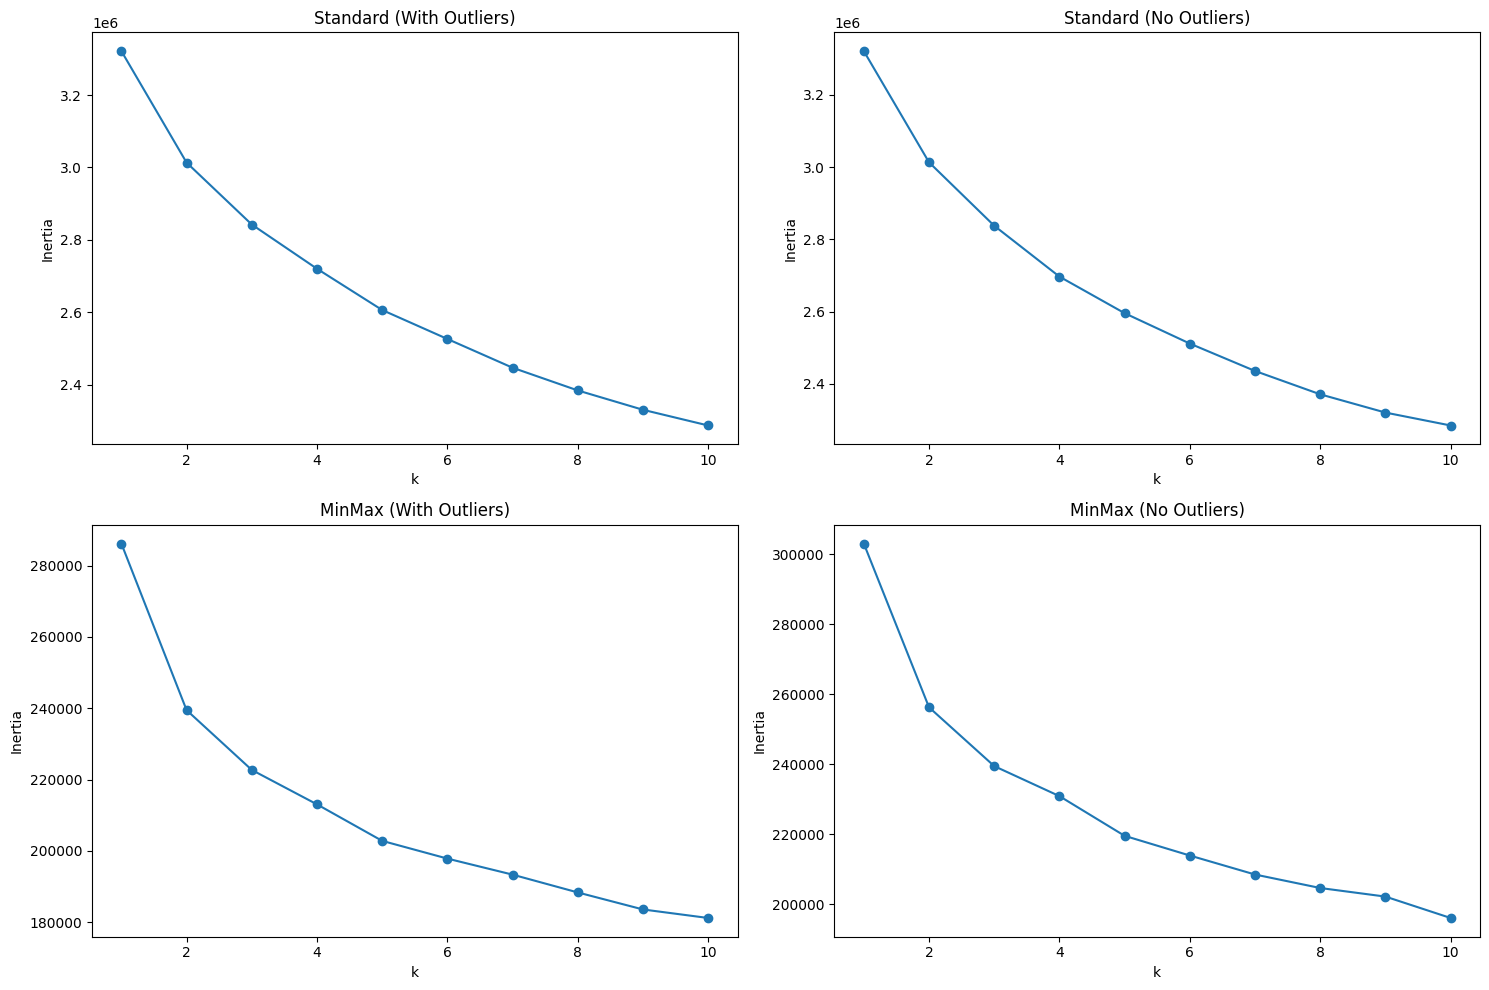

In [ ]:
# Dictionary to hold our test subjects. We will use this to run KMeans on all 4 variations of the dataset and compare their inertia scores
datasets = {
    "Standard (With Outliers)": X_train_WITH_outliers_norm,
    "Standard (No Outliers)": X_train_WITHOUT_outliers_norm,
    "MinMax (With Outliers)": X_train_WITH_outliers_scal,
    "MinMax (No Outliers)": X_train_WITHOUT_outliers_scal
}

ut.plt.figure(figsize=(15, 10))

for i, (name, data) in enumerate(datasets.items()):
    inertia = []
    for k in range(1, 11):
        km = KMeans(n_clusters= k, random_state= 10, n_init= 10)
        km.fit(data)
        inertia.append(km.inertia_)
    
    ut.plt.subplot(2, 2, i+1)
    ut.plt.plot(range(1, 11), inertia, marker='o')
    ut.plt.title(name)
    ut.plt.xlabel('k')
    ut.plt.ylabel('Inertia')

ut.plt.tight_layout()
ut.plt.show()

## 9.1 Charts Conclusions
- Summary Table for the Exploration Cell.
- In the "No Outliers" plot, the "bend" at k=3 and k=5 is much sharper and cleaner. 
- This is because outliers act like noise that "blurs" the elbow, making it harder to see where the natural groups end.

| **Dataset Configuration** | **Elbow Clarity** | **Inertia Scale** | **Recommendation** |
| --- | --- |--- |--- | 
| **Standard + Outliers** | Poor (blurry) | Very High (10^6) | Avoid |
| **Standard + No Outliers** | Moderate | Very High (10^6) | Avoid |
| **MinMax + Outliers** | Good | Lower (10^5) | Risky (centroids get pulled) |
| **MinMax + No Outliers** | Excellent | Lower (10^5) | **CHAMPION for K-Means** |

## 9.2 Build the K-Means Model
- We will compare $k=3$ and $k=5$ to see if that extra complexity in $k=5$ actually reveals a hidden risk group that is buried when we only use 3 clusters.
- Here is the code to run both and compare their Risk Profiles.
- We will look at the Late Delivery Rate for each cluster to see which one is the Danger Zone.

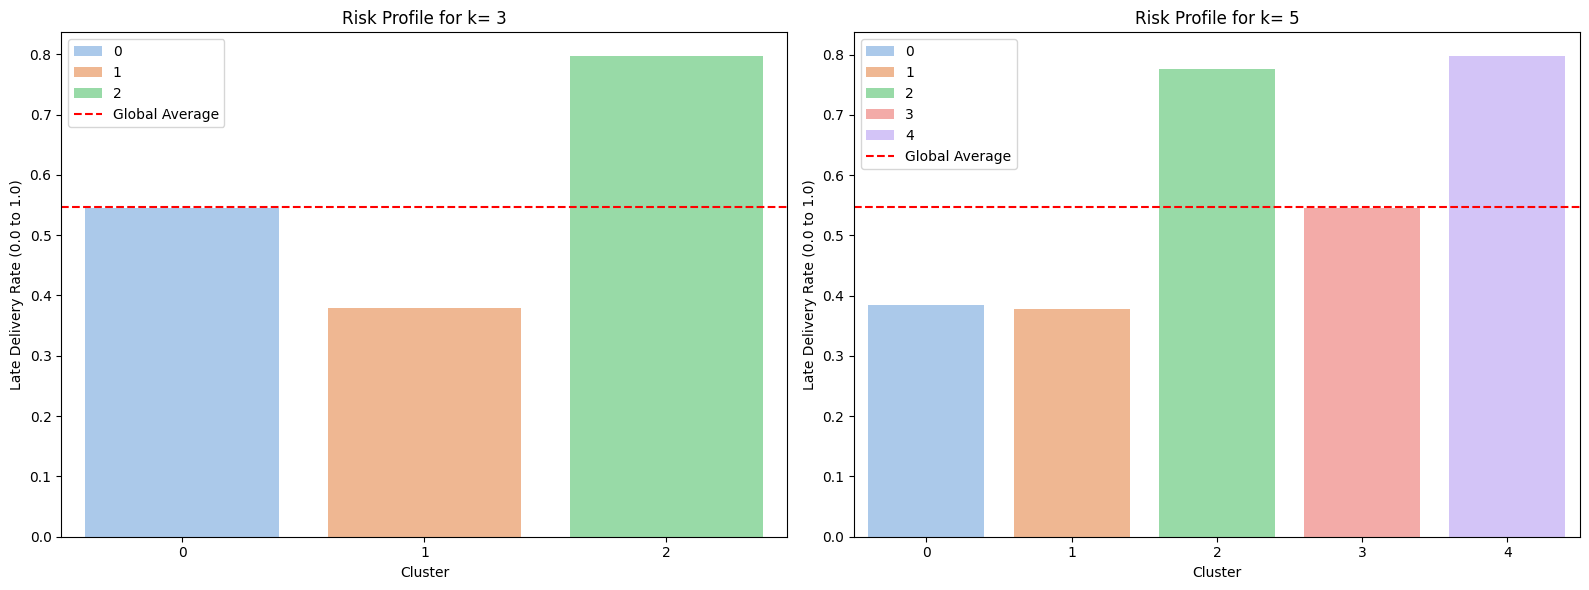

In [6]:
# We use the MinMax No Outliers data as decided
# We’ve configured the K-Means to be as stable as possible
# We are using k-means++ to ensure smart starting points
# Running it 10 times for each 'k' to guarantee we are seeing the most accurate clusters the data can provide.
data_for_clustering = X_train_WITHOUT_outliers_scal
y_labels = y_train.values.ravel()

results = {}

for k in [3, 5]:
    # Fit K-Means
    km = KMeans(n_clusters= k, init= 'k-means++', n_init= 10, random_state= 10)
    cluster_labels = km.fit_predict(data_for_clustering)
    
    # Create a temporary DataFrame to calculate risk
    temp_df = ut.pd.DataFrame({'Cluster': cluster_labels, 'Is_Late': y_labels})
    
    # Calculate % of late deliveries per cluster
    risk_per_cluster = temp_df.groupby('Cluster')['Is_Late'].mean()
    results[k] = risk_per_cluster

# --- VISUALIZATION ---
fig, ax = ut.plt.subplots(1, 2, figsize=(16, 6))

for i, k in enumerate([3, 5]):
    ut.sns.barplot(x= results[k].index, y= results[k].values, ax= ax[i], hue= results[k].index, palette= 'pastel')
    ax[i].set_title(f'Risk Profile for k= {k}')
    ax[i].set_ylabel('Late Delivery Rate (0.0 to 1.0)')
    ax[i].axhline(y_labels.mean(), color= 'red', linestyle= '--', label= 'Global Average')
    ax[i].legend()

ut.plt.tight_layout()
ut.plt.show()

### 9.2.1 K Selection Conclusion
- **The Verdict**: Which **k** should we choose?
- We recommend going with **k=3** for the final analysis. 
    - **why**: Clarity: In **k=5**, Clusters 2 and 4 show almost identical risk profiles (both around 80% late). 
    - Splitting them into two doesn't provide new "risk" information; it just makes the strategy more complicated.
    - **Actionability**: Telling DataCo team that there are three distinct tiers—Safe, Average, and High Risk—is a much more powerful business narrative than having five clusters where several overlap in behavior.

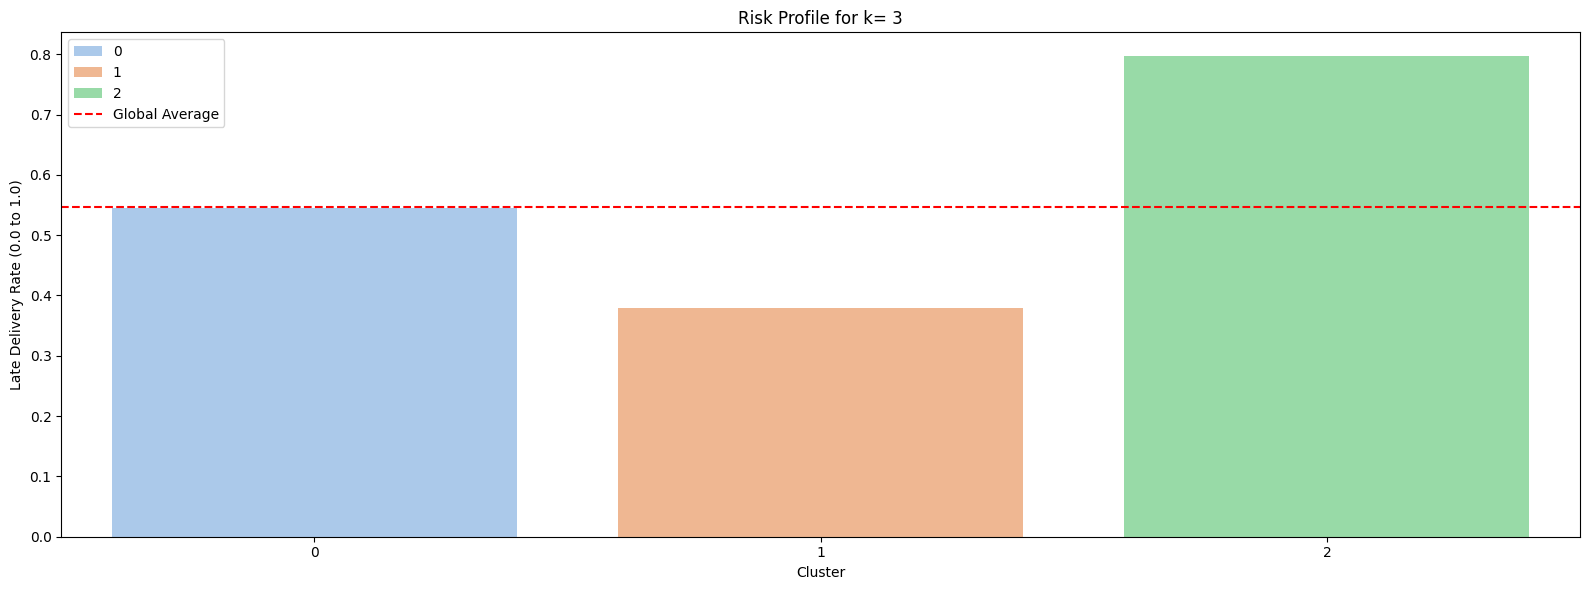

In [8]:
# Run analysis with K= 3 as decided after the elbow method and visual inspection of the risk profiles 
# This will be our final clustering analysis to identify risk profiles in the data
data_for_clustering = X_train_WITHOUT_outliers_scal
y_labels = y_train.values.ravel()

# Fit K-Means
km = KMeans(n_clusters= 3, init= 'k-means++', n_init= 10, random_state= 10)
cluster_labels = km.fit_predict(data_for_clustering)

# Create a temporary DataFrame to calculate risk
temp_df = ut.pd.DataFrame({'Cluster': cluster_labels, 'Is_Late': y_labels})

# Calculate % of late deliveries per cluster
risk_per_cluster = temp_df.groupby('Cluster')['Is_Late'].mean()

# --- VISUALIZATION ---
fig, ax = ut.plt.subplots(1, 1, figsize=(16, 6))

ut.sns.barplot(x= risk_per_cluster.index, y= risk_per_cluster.values, ax= ax, hue= risk_per_cluster.index, palette= 'pastel')
ax.set_title('Risk Profile for k= 3')
ax.set_ylabel('Late Delivery Rate (0.0 to 1.0)')
ax.axhline(y_labels.mean(), color= 'red', linestyle= '--', label= 'Global Average')
ax.legend()

ut.plt.tight_layout()
ut.plt.show()

## 9.3 "Sync" the Clusters

In [9]:
# 1. Re-assign the labels to the working dataframe in memory
# We use the k= 3 labels since that was our chosen 'Champion' for clustering
X_train_WITHOUT_outliers['Cluster'] = cluster_labels 

# 2. Run the analysis
cluster_summary = X_train_WITHOUT_outliers.groupby('Cluster').mean()

# 3. Add a column for the count so we know how big each group is
cluster_summary['Order_Count'] = X_train_WITHOUT_outliers['Cluster'].value_counts()

# 4. Show the results
print("--- DATACO BUSINESS SEGMENT ANALYSIS (k= 3) ---")
print(ut.tabulate(cluster_summary, headers='keys', tablefmt='grid'))

--- DATACO BUSINESS SEGMENT ANALYSIS (k= 3) ---
+-----------+-------------------------------+---------------------+-----------------------+----------------------------+---------------------------+-----------------------+------------+---------------------+---------------------+------------------------+------------------------+----------------------+-----------------------+------------------+---------------------+-------------------+--------------------+---------------------+------------------------+--------------------+----------------------+------------------+-------------------------+---------------+
|   Cluster |   Days_for_shipment_scheduled |   Benefit_per_order |   Order_Item_Discount |   Order_Item_Discount_Rate |   Order_Item_Profit_Ratio |   Order_Item_Quantity |   Type_num |   Category_Name_num |   Customer_City_num |   Customer_Country_num |   Customer_Segment_num |   Customer_State_num |   Department_Name_num |   Order_City_num |   Order_Country_num |   Order_State_num |   O

In [10]:
# Save the new version with the Cluster labels included
X_train_WITHOUT_outliers.to_csv('../data/processed/X_train_WITHOUT_outliers_WITH_CLUSTERS.csv', index= False)

### 9.3.1 Conclusion on Cluster Dataset
- **Summary of the 3 Business Segments**

| **Segment** | **Behavior** | **Risk Level** | **Key Characteristic** |
| --- | --- |--- |--- |
| **Cluster 1** | Standard Logistics | **Low (38%)** | Reliable 4-day window. |
| **Cluster 0** | Rapid Logistics | **Medium (55%)** | Standard 3-day window. |
| **Cluster 2** | Critical/Express | **High (80%)** | Unrealistic 1.3-day window. |

## 9.4 Analyzing the "Danger Zone" Risk (80% risk in Cluster 2 now)

In [11]:
# 1. Update the names to match your actual DataFrame columns
key_features = [
    'shipping_day_num',            # This is the factorized day of the week for shipping
    'Days_for_shipment_scheduled', # The scheduled target
    'Benefit_per_order',           # Financial impact
    'Price_Per_Unit'               # Value impact
]

# 2. Show the comparison
print("--- BUSINESS CHARACTERISTICS BY CLUSTER ---")
print(ut.tabulate(cluster_summary[key_features], headers= 'keys', tablefmt= 'grid'))

stress_analysis = cluster_summary[['Days_for_shipment_scheduled', 'Shipping_Mode_num']]
print("--- LOGISTICS PRESSURE ANALYSIS ---")
print(ut.tabulate(stress_analysis, headers='keys', tablefmt='grid'))

--- BUSINESS CHARACTERISTICS BY CLUSTER ---
+-----------+--------------------+-------------------------------+---------------------+------------------+
|   Cluster |   shipping_day_num |   Days_for_shipment_scheduled |   Benefit_per_order |   Price_Per_Unit |
+===========+====================+===============================+=====================+==================+
|         0 |            2.99837 |                       2.94767 |             20.4554 |          138.311 |
+-----------+--------------------+-------------------------------+---------------------+------------------+
|         1 |            3.01046 |                       4       |             21.1661 |          139.395 |
+-----------+--------------------+-------------------------------+---------------------+------------------+
|         2 |            3.00144 |                       1.34855 |             20.9407 |          138.19  |
+-----------+--------------------+-------------------------------+---------------------+----

## 9.5 Origin vs. Destination Scatter Plot

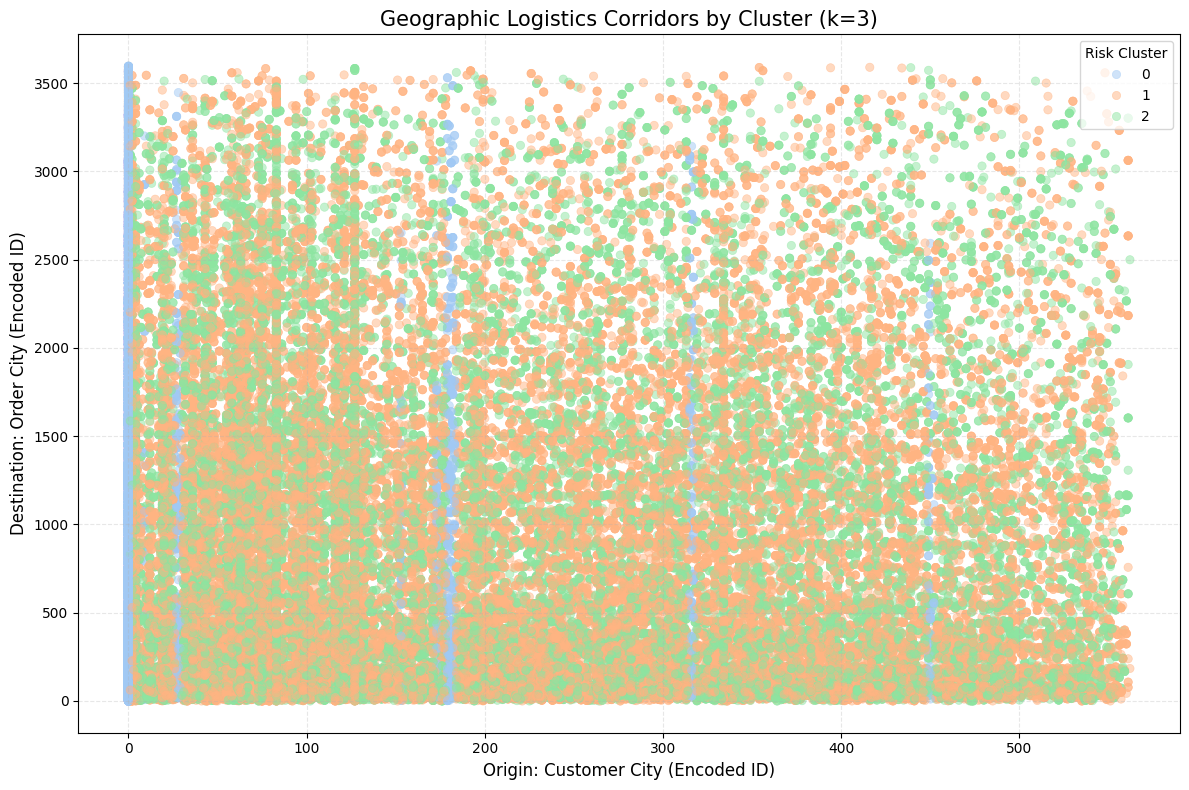

In [13]:
# We use the unscaled data for clearer axis labels, colored by our k= 3 clusters
ut.plt.figure(figsize=(12, 8))

ut.sns.scatterplot(
    data= X_train_WITHOUT_outliers, 
    x= 'Customer_City_num',   # Origin
    y= 'Order_City_num',      # Destination
    hue= 'Cluster', 
    palette= 'pastel',
    alpha= 0.5,               # Transparency helps see the density of orders
    edgecolor= None
)

ut.plt.title('Geographic Logistics Corridors by Cluster (k=3)', fontsize= 15)
ut.plt.xlabel('Origin: Customer City (Encoded ID)', fontsize= 12)
ut.plt.ylabel('Destination: Order City (Encoded ID)', fontsize= 12)
ut.plt.grid(True, linestyle= '--', alpha= 0.3)
ut.plt.legend(title= 'Risk Cluster', loc= 'upper right')

ut.plt.tight_layout()
ut.plt.show()

# Step 10. Feeling Confident (test the model)